In [1]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/Users/elysiaye/alignment')

from alignment import caiman_memmap_reader, minmax_scaler
from registration import sitkalignment

cv2 not available


### Set up folder and select fish to align

In [ ]:
# Optional quick setup (main config is in the dedicated config cell below)
data_folder = Path('/Volumes/Kobi/DOI_animals_good')
fish_name = 'elavl3H2BGCaMP6s_7dpf_DOI_50ugml_31_20251007'
plane = 2
selected_plane = 2

exp_folder = data_folder / fish_name
_mcorr_dir = exp_folder / 'mcorr_tiff_outputs'
if not _mcorr_dir.is_dir():
    raise FileNotFoundError(f"Missing mcorr output folder: {_mcorr_dir}")
_std_plane_re = re.compile(r'plane(\d+)', re.IGNORECASE)
_matches = [
    p
    for p in _mcorr_dir.glob('STD*')
    if p.is_file() and (m := _std_plane_re.search(p.name)) and int(m.group(1)) == selected_plane
]
if not _matches:
    _std_names = sorted(p.name for p in _mcorr_dir.glob('STD*') if p.is_file())
    raise FileNotFoundError(
        f"No STD* file in {_mcorr_dir} with plane index {selected_plane}. Found STD files: {_std_names}"
    )
if len(_matches) > 1:
    raise ValueError(f"Multiple STD* files match plane{selected_plane}: {_matches}")
external_std_tiff = _matches[0]

### Load in mapZebrain chosen plane

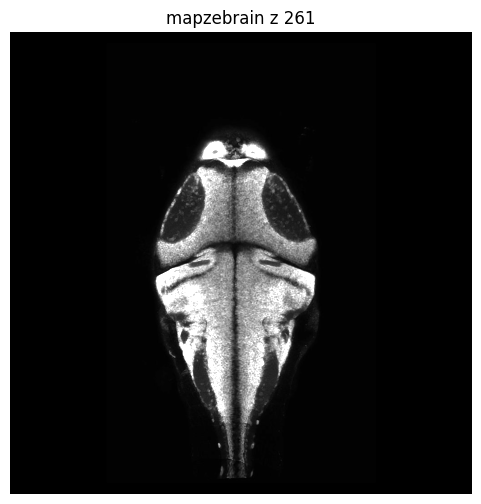

In [9]:
# mapzebrain plane preview (self-contained)
# Tuning: if global alignment is "almost" but A/P or midline is off, try adjacent slices (±1–2).
selected_mapzebrain_z = 261
mapzebrain_img_path = Path(r'./reference_images/hindbrain/mapzebrain/T_AVG_HuCD.tif')

# Load stack here so this cell can run independently.
_source_stack = tifffile.imread(str(mapzebrain_img_path))
if not (0 <= selected_mapzebrain_z < _source_stack.shape[0]):
    raise ValueError(
        f'selected_mapzebrain_z={selected_mapzebrain_z} out of range for stack with '
        f'{_source_stack.shape[0]} slices'
    )

mapzebrain_native = _source_stack[selected_mapzebrain_z, :, :]
mapzebrain_native_shape = mapzebrain_native.shape
source_img = mapzebrain_native
source_img = sitkalignment.embed_image(source_img, 1024)  # matching image sizes to 1024x1024

max_val = float(source_img.max())
if max_val > 0:
    source_img = source_img / max_val  # rescaling pixel brightness --> this is normalizing the image so the new maximum is 1 and everything else is scaled down proportionally
source_img *= 2**10 # mutipling by 2^10 aka 1024

plt.figure(figsize=(6, 6))
# Tuning: display only; does not affect registration. Change vmax to see dim structure.
plt.imshow(source_img, cmap='gray', vmax=700)
plt.title(f'mapzebrain z {selected_mapzebrain_z}')
plt.axis('off')
plt.show()

### Visualize experiment and atlas planes side by side + merged

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


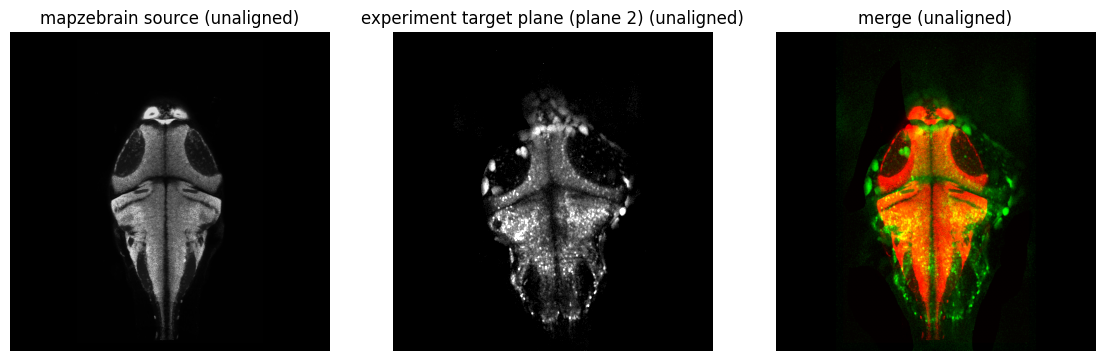

In [19]:
# Unaligned visualization: mapzebrain source, experiment target, RGB merge.
# (Left = `source_img`, center = `plot_img` — do not alias.)
#
# Requires: `source_img`, `plot_img`, `plane`.

# Intensity windows — same pattern as `3_brain_alignment_elysia.ipynb` (tune for display and for registration).
target_vmin = 50
target_vmax = 450
source_vmax = 1200

# Registration masks: exclude top bands from the metric only (full mapzebrain still warps).
EXCLUDE_TOP_ROWS_FIXED = 0  # experiment / plot_img (embedded 1024² rows; row 0 = top)

# Precomputed STD / projection TIFF: apply the same steps as `_std_plane_image` so shapes match `source_img` (1024² embedded).
_raw = np.asarray(tifffile.imread(external_std_tiff), dtype=np.float64)
if _raw.ndim == 3:
    _raw = _raw[0]  # e.g. plane0 in filename; change index if you align another z-slice
elif _raw.ndim != 2:
    raise ValueError(f"Expected 2D or 3D array from STD tiff, got shape {_raw.shape}")
_m = float(np.nanmax(_raw))
plot_img = _raw
if _m > 0:
    plot_img = plot_img / _m
plot_img *= 2**10
plot_img = np.rot90(plot_img, k=1)
plot_img = sitkalignment.embed_image(plot_img, 1024)

if EXCLUDE_TOP_ROWS_FIXED:
    plot_img[:EXCLUDE_TOP_ROWS_FIXED, :] = 0

registration_fixed_mask = sitkalignment.registration_mask_from_exclusions(
    plot_img.shape, exclude_top=EXCLUDE_TOP_ROWS_FIXED
)
registration_moving_mask = np.ones(source_img.shape, dtype=np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(source_img, cmap="gray", vmin=0, vmax=source_vmax)
ax[1].imshow(plot_img, cmap="gray", vmin=target_vmin, vmax=target_vmax)

merge = np.zeros((source_img.shape[0], source_img.shape[1], 3))
merge[:, :, 0] = 2 * source_img / max(float(source_img.max()), 1.0)
merge[:, :, 1] = 2 * plot_img / max(float(plot_img.max()), 1.0)
ax[2].imshow(merge)

ax[0].set_title("mapzebrain source (unaligned)")
ax[1].set_title(f"experiment target plane (plane 2) (unaligned)")
ax[2].set_title("merge (unaligned)")
for a in ax:
    a.axis("off")
plt.show()


### Run alignment

In [20]:
%%time
# Primary alignment — same `minmax_scaler` + `register_image2` pattern as `3_brain_alignment_elysia.ipynb`.
# Elastix: fixed = experiment plane, moving = mapzebrain → warped atlas in experiment coordinates.
# Tune `target_vmin` / `target_vmax` / `source_vmax` in the unaligned visualization cell above.
# Masks (`registration_*_mask` from the cell above) exclude top bands from the metric only;
# do not zero `_reg_source` — excluded atlas rows still warp with the estimated transform.
# Geometry: mapzebrain slice = `selected_mapzebrain_z`; functional plane = `selected_plane`.

save_path = exp_folder.joinpath(f"alignment_rev_plane{selected_plane}")

_reg_plot = minmax_scaler(plot_img, vmin=target_vmin, vmax=target_vmax)
_reg_source = minmax_scaler(source_img, vmin=0, vmax=source_vmax)

scale_penalties = [150]
iterations = [(10000, 500)]

registered_images = []
for sp in scale_penalties:
    for it in iterations:
        registered_image = sitkalignment.register_image2(
            _reg_plot,
            _reg_source,
            save_path,
            scalePenalty=sp,
            iterations=it,
            fixed_mask=registration_fixed_mask,
            moving_mask=registration_moving_mask,
        )
        registered_images.append(registered_image)

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-fMask    unspecified, so no fixed mask used
-mMask    unspecified, so no moving mask used
-out      ./
-threads  unspecified, so all available threads are used
  The default value "true" is used instead.

  From elastix 4.8 it defaults to true!
This may change the behavior of your registrations considerably.

Command line options from TransformBase:
-t0       unspecified, so no initial transform used

Reading images...
Reading images took 0 ms.

  A default pyramid schedule is used.
  A default pyramid schedule is used.
  The default value "false" is used instead.
  The default value "GeometricalCenter" is used instead.
Transform parameters are initialized as: [1, 0, 0, 1, 0, 0]
InitializeTransform took 0.00s
Scales are estimated automatically.
Scales for transform parameters are: [88400.25, 88400.25, 88400.25, 88400.25, 1, 1]
Initialization of all components (before registration) took: 3 ms.
Preparation of the image pyrami

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


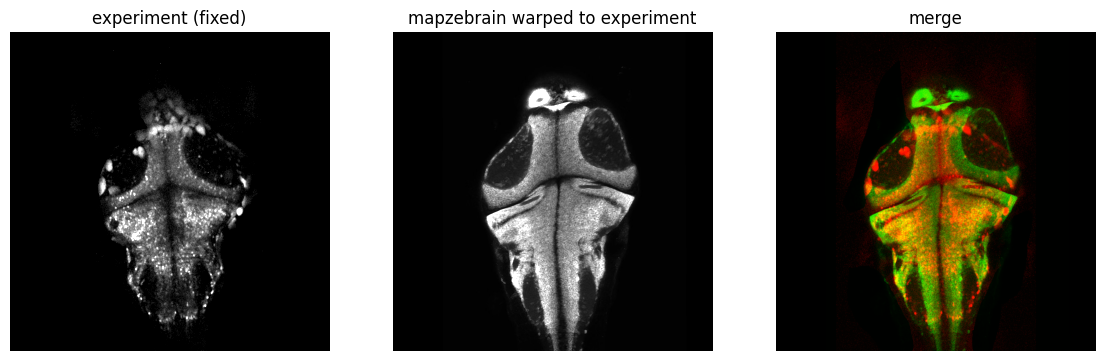

In [21]:
target_img = plot_img
for registered_image in registered_images:
	fig, ax = plt.subplots(1, 3, figsize=(14, 6))

	ax[0].imshow(
		target_img,
		cmap="gray",
		vmin=target_vmin,
		vmax=target_vmax,
	)
	ax[1].imshow(
		registered_image,
		cmap="gray",
		vmin=0,
		vmax=1000,
	)

	[a.axis("off") for a in ax]

	merge = np.zeros((target_img.shape[0], target_img.shape[1], 3))
	merge[:, :, 0] = 3 * target_img / max(float(target_img.max()), 1.0)
	merge[:, :, 1] = 1 * registered_image / max(float(registered_image.max()), 1.0)
	ax[-1].imshow(merge)

	ax[0].set_title("experiment (fixed)")
	ax[1].set_title("mapzebrain warped to experiment")
	ax[-1].set_title("merge")
	plt.show()

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006179 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 813
  The input points are transformed.
  The transformed p

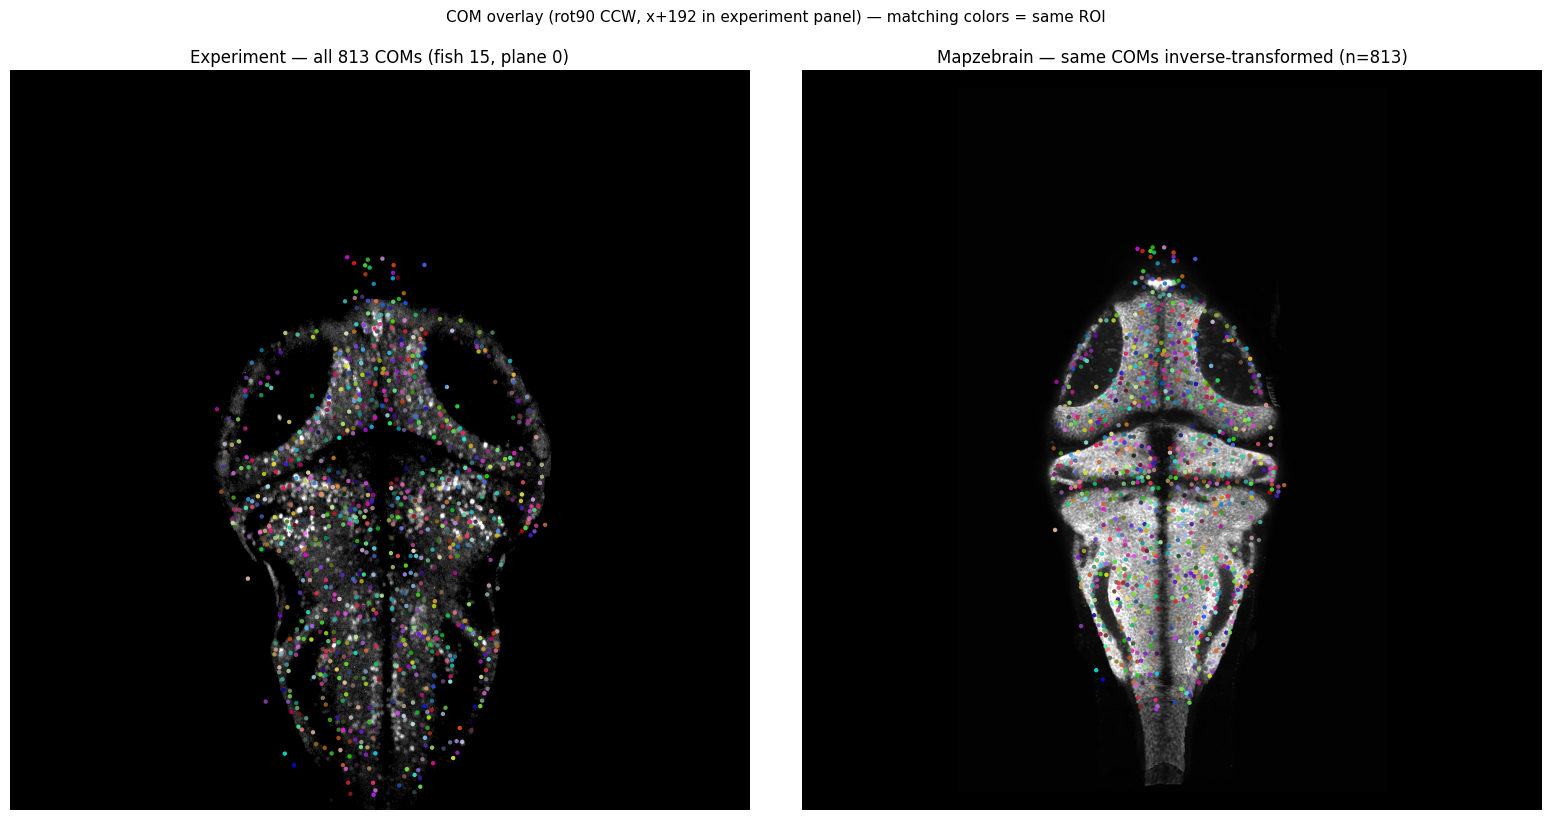

In [11]:
# Diagnostic: all ROI COMs for this fish/plane (`com_to_target_xy` → experiment / `plot_img` frame).
# After registration: same COMs inverse-transformed to mapzebrain (`source_img`). One row, two panels; each ROI gets a random RGB (same in both panels).
# Requires: `exp_folder`, `data_folder`, `source_img`, `plot_img`, registration output under `alignment_rev_plane*`.

W_EMBED = 1024
SHIFT_X_CURRENT = (1024 - 640) // 2

if "com_to_target_xy" not in globals():
    def com_to_target_xy(x, y):
        px, py = float(x), float(y)
        ox, oy = py, W_EMBED - 1 - px
        return (ox + SHIFT_X_CURRENT, oy)

if "fish_id" not in globals():
    fish_id = int(exp_folder.name.split("_")[-2])

_plane = int(globals().get("plane", globals().get("selected_plane", 0)))

_h5_candidates = [
    exp_folder / "temporal_pack_compact.h5",
    data_folder / "temporal_pack_compact.h5",
]
_h5 = next((p for p in _h5_candidates if p.is_file()), None)
if _h5 is None:
    raise FileNotFoundError(
        "temporal_pack_compact.h5 not found. Tried:\n  "
        + "\n  ".join(str(p) for p in _h5_candidates)
    )

_tdf = df if "df" in globals() else pd.read_hdf(_h5)
_roi_plane = _tdf[(_tdf["fish_id"] == fish_id) & (_tdf["plane"] == _plane)]


def _unpack_com(c):
    v = np.asarray(c, dtype=float).ravel()
    if v.size < 2:
        raise ValueError(f"COM must have at least 2 values, got {c!r}")
    return float(v[0]), float(v[1])


_all_pts = [com_to_target_xy(*_unpack_com(c)) for c in _roi_plane["com"]]

_tvmin = globals().get("target_vmin", 0)
_tvmax = globals().get("target_vmax", 1000)

if "plot_img" not in globals():
    raise ValueError(
        "No target image for overlay. Rerun the unaligned visualization cell (defines plot_img)."
    )
_tgt = plot_img

save_path = exp_folder.joinpath(f"alignment_rev_plane{_plane}")
if not save_path.is_dir():
    raise FileNotFoundError(
        f"Elastix output not found: {save_path}. Run the registration cell first (writes transform_pmap_*.txt)."
    )
mypoints = _all_pts
rev_points = sitkalignment.transform_points(Path(save_path), mypoints)

# Inverse-transformed COMs in mapzebrain (moving) coordinates — same column as the region-assignment cell.
_COM_MAP_COL = "com_aligned_mapzebrain"
if _COM_MAP_COL not in _tdf.columns:
    _tdf[_COM_MAP_COL] = pd.Series(index=_tdf.index, dtype=object)
for _ix, _rp in zip(_roi_plane.index, rev_points):
    _tdf.at[_ix, _COM_MAP_COL] = (float(_rp[0]), float(_rp[1]))
if "df" not in globals():
    df = _tdf

_src_vmax = globals().get("source_vmax", 1000)
_n = len(mypoints)
_rng = np.random.default_rng()
_pt_colors = _rng.random((_n, 3)) if _n else np.empty((0, 3))
xs_e = np.array([p[0] for p in mypoints], dtype=float)
ys_e = np.array([p[1] for p in mypoints], dtype=float)
xs_m = np.array([p[0] for p in rev_points], dtype=float)
ys_m = np.array([p[1] for p in rev_points], dtype=float)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 8))
ax0.imshow(_tgt, cmap="gray", vmin=_tvmin, vmax=_tvmax)
ax0.scatter(xs_e, ys_e, c=_pt_colors, s=10, alpha=0.85, linewidths=0)
ax0.set_title(
    f"Experiment — all {len(mypoints)} COMs (fish {fish_id}, plane {_plane})"
)
ax0.axis("off")

ax1.imshow(source_img, cmap="gray", vmin=0, vmax=_src_vmax)
ax1.scatter(xs_m, ys_m, c=_pt_colors, s=10, alpha=0.85, linewidths=0)
ax1.set_title(f"Mapzebrain — same COMs inverse-transformed (n={len(rev_points)})")
ax1.axis("off")

fig.suptitle(
    f"COM overlay (rot90 CCW, x+{SHIFT_X_CURRENT} in experiment panel) — matching colors = same ROI",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006101 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 20
  The input points are transformed.
  The transformed po

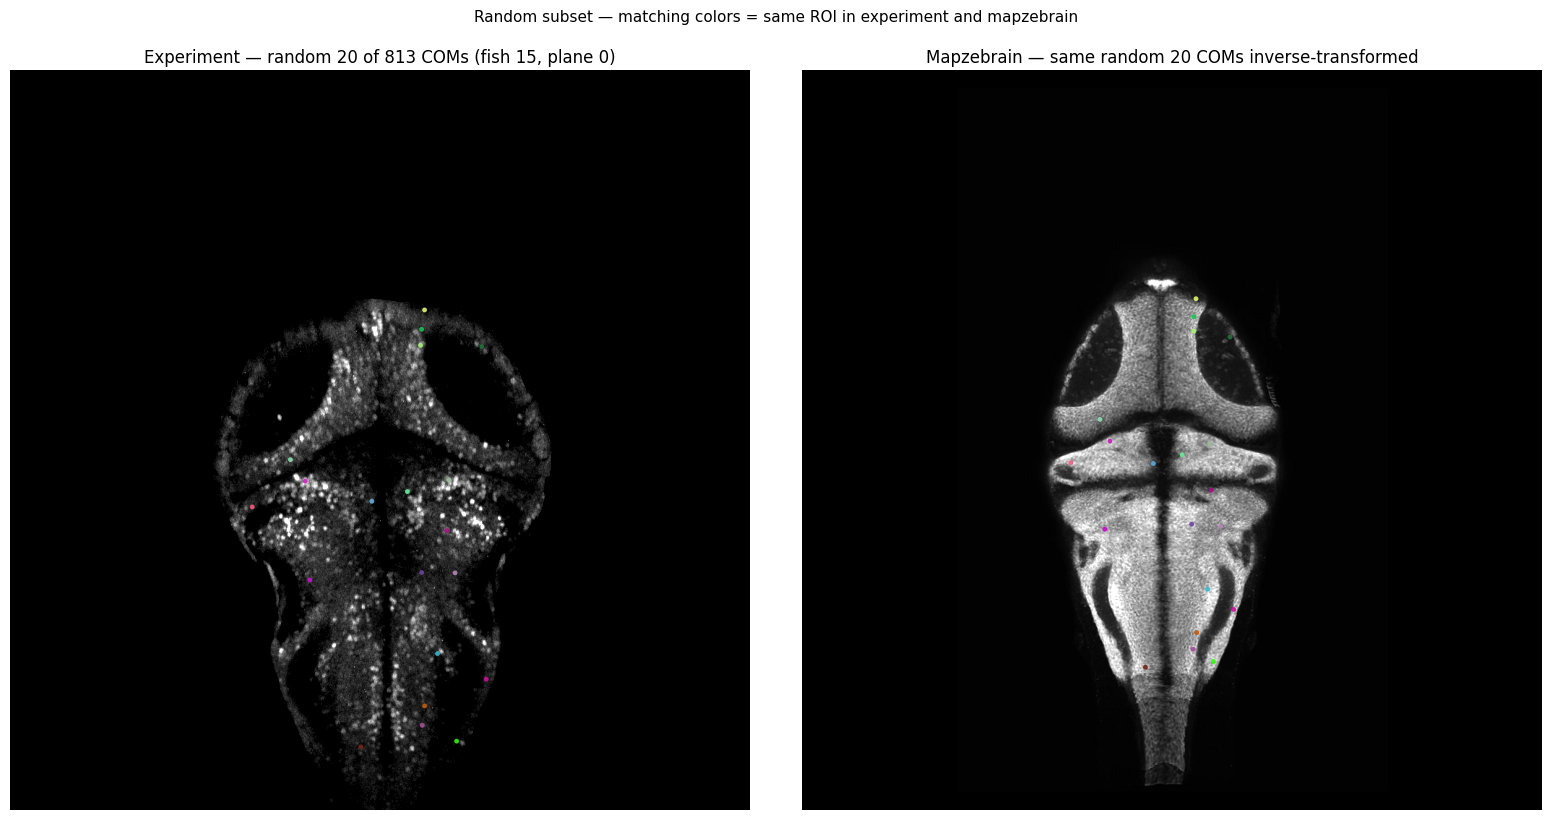

In [12]:
# Optional: random subset of the same ROI COMs (`_all_pts`) → inverse transform to mapzebrain.
# Run the all-COM diagnostic cell above first (defines `_all_pts`, `_plane`, `fish_id`, …).

n_random_points = 20

if "_all_pts" not in globals() or not _all_pts:
    raise ValueError(
        "Run the all-COM diagnostic cell above first — it defines `_all_pts`."
    )

_plane_r = int(globals().get("_plane", globals().get("plane", globals().get("selected_plane", 0))))
_k = min(int(n_random_points), len(_all_pts))
_ix = random.sample(range(len(_all_pts)), k=_k)
sample_pts = [_all_pts[i] for i in _ix]

save_path_r = exp_folder.joinpath(f"alignment_rev_plane{_plane_r}")
if not save_path_r.is_dir():
    raise FileNotFoundError(
        f"Elastix output not found: {save_path_r}. Run the registration cell first."
    )
rev_points_sample = sitkalignment.transform_points(Path(save_path_r), sample_pts)

_tvmin = globals().get("target_vmin", 0)
_tvmax = globals().get("target_vmax", 1000)
_src_vmax = globals().get("source_vmax", 1000)
_kn = len(sample_pts)
_rng_s = np.random.default_rng()
_pt_colors_s = _rng_s.random((_kn, 3)) if _kn else np.empty((0, 3))
xs_s = np.array([p[0] for p in sample_pts], dtype=float)
ys_s = np.array([p[1] for p in sample_pts], dtype=float)
xs_rs = np.array([p[0] for p in rev_points_sample], dtype=float)
ys_rs = np.array([p[1] for p in rev_points_sample], dtype=float)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 8))
ax0.imshow(plot_img, cmap="gray", vmin=_tvmin, vmax=_tvmax)
ax0.scatter(xs_s, ys_s, c=_pt_colors_s, s=12, alpha=0.9, linewidths=0)
ax0.set_title(
    f"Experiment — random {len(sample_pts)} of {len(_all_pts)} COMs (fish {fish_id}, plane {_plane_r})"
)
ax0.axis("off")

ax1.imshow(source_img, cmap="gray", vmin=0, vmax=_src_vmax)
ax1.scatter(xs_rs, ys_rs, c=_pt_colors_s, s=12, alpha=0.9, linewidths=0)
ax1.set_title(
    f"Mapzebrain — same random {len(rev_points_sample)} COMs inverse-transformed"
)
ax1.axis("off")

fig.suptitle(
    "Random subset — matching colors = same ROI in experiment and mapzebrain",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


## Multi-plane ROIs with a **single** transform (reference plane)



Register **once** with the primary alignment cells so **`alignment_rev_plane{plane}/`** exists for your reference functional plane (usually `plane == 0`). The **same** inverse transform is applied to **every** ROI COM (`com_aligned_mapzebrain`), regardless of functional plane.



Per-plane **experiment images** come from **`mesmerize-batch/`** memmaps (same memmap source as `3_brain_alignment_elysia.ipynb`, but **rot90 k=1** and **× 2^10** here so experiment frames match the STD / `com_to_target_xy` convention used in this notebook).



**`EXPERIMENT_TO_MAPZEBRAIN_Z`** (next cell): declare which **functional plane** you want next to which **mapzebrain z** slice in the QC grid. Use a **list of `(exp_plane, atlas_z)` tuples** (row order = list order) or a **`dict`** `{exp_plane: atlas_z}` (row order = insertion order). That is how you tell the notebook which atlas image to plot for each experiment plane when checking that the single transform still looks reasonable across depth.



**Geometry note:** Elastix is 2D: inverse-transformed \((x,y)\) are strictly correct in the **atlas slice used as the moving image** during registration (typically `selected_mapzebrain_z`). On **other** z slices, the same \((x,y)\) are overlaid for **visual** comparison at the depth you pair by hand, not a separate 3D warp.



In [13]:
# Build `target_img_by_plane` from mesmerize CaImAn memmaps (no per-plane STD TIFFs).
# Uses a separate batch dataframe so we do not overwrite `df` from temporal_pack_compact.h5.
ALIGNMENT_REFERENCE_PLANE = int(globals().get("plane", globals().get("selected_plane", 0)))
batch_path = exp_folder.joinpath("mesmerize-batch/batch.pickle")
if not batch_path.is_file():
    raise FileNotFoundError(f"Missing mesmerize batch pickle: {batch_path}")
_mbatch_df = pd.read_pickle(batch_path)
_mbatch_df = _mbatch_df[_mbatch_df["algo"] == "mcorr"]
uuid_to_plane = {}
plane_col = None
for candidate in ["plane", "z", "z_plane", "slice", "plane_idx", "plane_index"]:
    if candidate in _mbatch_df.columns:
        plane_col = candidate
        break
if plane_col is not None:
    uuid_to_plane.update(
        {
            str(row.uuid): int(row[plane_col])
            for _, row in _mbatch_df[["uuid", plane_col]].dropna().iterrows()
        }
    )
for _, row in _mbatch_df.iterrows():
    uid = str(row.uuid)
    if uid in uuid_to_plane:
        continue
    for field in ["item_name", "input_movie_path"]:
        if field not in _mbatch_df.columns:
            continue
        text = str(row[field])
        m = re.search(r"img_stack[_\-\s]?(\d+)", text, flags=re.IGNORECASE)
        if m:
            uuid_to_plane[uid] = int(m.group(1))
            break
filenames = set(_mbatch_df.uuid.astype(str))
target_items = []
with os.scandir(exp_folder.joinpath("mesmerize-batch")) as entries:
    for entry in entries:
        if entry.name in filenames:
            with os.scandir(entry.path) as subentries:
                for subentry in subentries:
                    if not subentry.name.endswith(".mmap") or subentry.name.startswith("._"):
                        continue
                    detected_plane = uuid_to_plane.get(entry.name)
                    if detected_plane is None:
                        m = re.search(
                            r"(?:^|[_\-\s])(plane|z|slice|img_stack)[_\-\s]?(\d+)(?:[_\-\s]|$)",
                            subentry.path,
                            flags=re.IGNORECASE,
                        )
                        if m:
                            detected_plane = int(m.group(2))
                    target_items.append((subentry.path, detected_plane, entry.name))
target_items.sort(
    key=lambda x: (
        x[1] is None,
        x[1] if x[1] is not None else 10**9,
        x[2],
        x[0],
    )
)
target_img_lst = []
target_img_by_plane = {}
plane_to_uuid = {}
for img_path, detected_plane, uid in target_items:
    img_stack = caiman_memmap_reader(img_path, mode="r")
    target_img = np.nanstd(img_stack, axis=0)
    m = float(np.nanmax(target_img))
    if m > 0:
        target_img = target_img / m
    target_img *= 2**10  # match STD / registration scaling in this notebook
    target_img = np.rot90(target_img, k=1)  # match `plot_img` + com_to_target_xy in cells above
    target_img = sitkalignment.embed_image(target_img, 1024)
    target_img_lst.append(target_img)
    if detected_plane is not None:
        target_img_by_plane[detected_plane] = target_img
        plane_to_uuid[detected_plane] = uid
print(f"Loaded {len(target_img_lst)} memmap projection(s); planes: {sorted(target_img_by_plane.keys())}")
_mapze_path = Path(
    globals().get("mapzebrain_img_path", Path(r"./reference_images/hindbrain/mapzebrain/T_AVG_HuCD.tif"))
)
with tifffile.TiffFile(_mapze_path) as _tf:
    _nz_atlas = int(_tf.series[0].shape[0])

Loaded 11 memmap projection(s); planes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [14]:
# --- edit: experiment functional plane -> mapzebrain z for that QC row (list order = row order) ---
EXPERIMENT_TO_MAPZEBRAIN_Z = [
    (0, 292),
    (1, 272),
    (2, 252),
    (3, 232),
    (4, 212),
    (5, 192),
    (6, 172),
    (7, 152),
    (8, 132),
    (9, 112),
    (10, 92),
]
if isinstance(EXPERIMENT_TO_MAPZEBRAIN_Z, dict):
    _qc_iter = list(EXPERIMENT_TO_MAPZEBRAIN_Z.items())
elif isinstance(EXPERIMENT_TO_MAPZEBRAIN_Z, (list, tuple)):
    _qc_iter = list(EXPERIMENT_TO_MAPZEBRAIN_Z)
else:
    raise TypeError(
        "EXPERIMENT_TO_MAPZEBRAIN_Z must be a list of (exp_plane, atlas_z) tuples or dict exp_plane -> atlas_z"
    )
_seen_ep = set()
EXPERIMENT_ATLAS_QC_PAIRS = []
for _item in _qc_iter:
    if isinstance(_item, tuple) and len(_item) == 2:
        _ep, _mz = int(_item[0]), int(_item[1])
    else:
        raise TypeError(f"Expected (exp_plane, atlas_z), got {_item!r}")
    if _ep in _seen_ep:
        raise ValueError(f"Duplicate experiment plane {_ep} in EXPERIMENT_TO_MAPZEBRAIN_Z")
    _seen_ep.add(_ep)
    if not (0 <= _mz < _nz_atlas):
        raise ValueError(f"atlas z {_mz} for experiment plane {_ep} out of range [0, {_nz_atlas})")
    if _ep not in target_img_by_plane:
        print(f"[WARN] experiment plane {_ep} not in target_img_by_plane — QC will skip this row")
    EXPERIMENT_ATLAS_QC_PAIRS.append((_ep, _mz))
# If EXPERIMENT_TO_MAPZEBRAIN_Z is empty, the QC cell falls back to sorted planes + selected_mapzebrain_z.
if not EXPERIMENT_ATLAS_QC_PAIRS:
    print(
        "[WARN] EXPERIMENT_TO_MAPZEBRAIN_Z produced no pairs; QC cell will fall back to sorted planes."
    )
_atlas_stack_holder = {"arr": None}
def atlas_slice_embedded(z):
    if _atlas_stack_holder["arr"] is None:
        _atlas_stack_holder["arr"] = tifffile.imread(str(_mapze_path))
    stack = _atlas_stack_holder["arr"]
    s = np.asarray(stack[int(z)], dtype=np.float64)
    s = sitkalignment.embed_image(s, 1024)
    mx = float(np.max(s))
    if mx > 0:
        s = s / mx
    return s * (2**10)


In [15]:
# Single Elastix folder for all planes (inverse transform ROI COMs with this path).
ALIGNMENT_SAVE_PATH = exp_folder.joinpath(f"alignment_rev_plane{ALIGNMENT_REFERENCE_PLANE}")
if not ALIGNMENT_SAVE_PATH.is_dir():
    raise FileNotFoundError(
        f"Expected registration output at {ALIGNMENT_SAVE_PATH}. "
        "Run the primary `register_image2` cell for the reference plane first."
    )
print("ROI inverse-transform uses:", ALIGNMENT_SAVE_PATH.resolve())

ROI inverse-transform uses: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0


ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.009867 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 813
  The input points are transformed.
  The transformed p

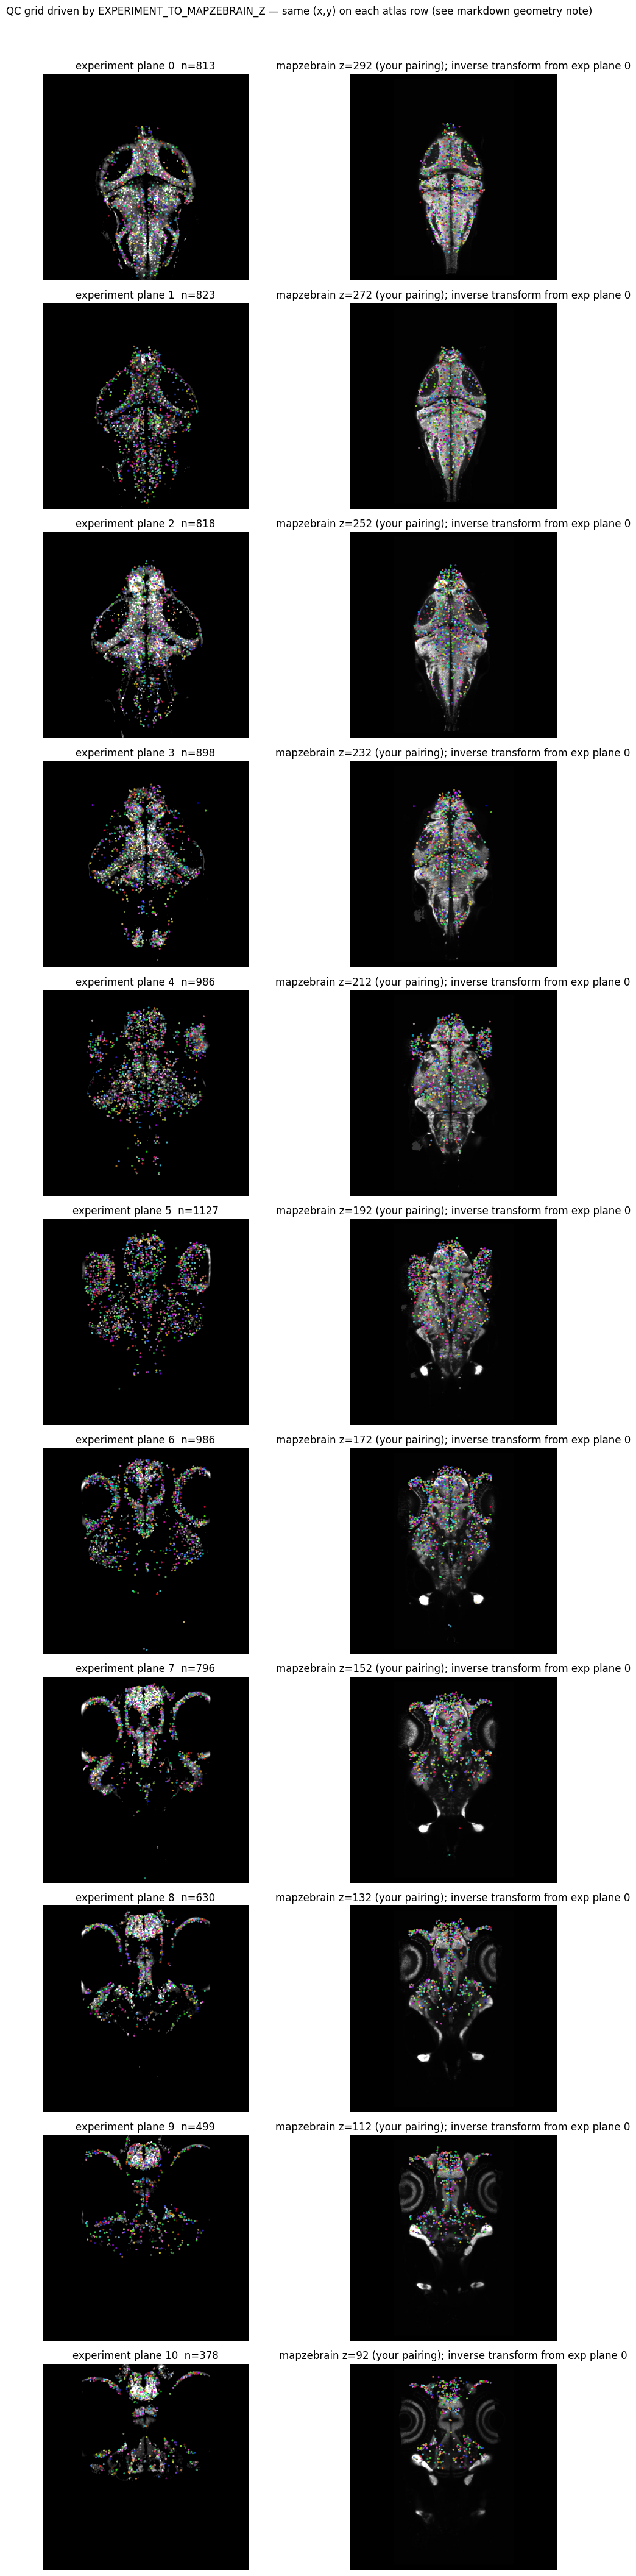

In [16]:
# QC: experiment plane (memmap) | atlas slice you paired for that plane. Same inverse transform for all COMs.
if "target_img_by_plane" not in globals() or not target_img_by_plane:
    raise RuntimeError("Run the mesmerize memmap cell above first.")
if "ALIGNMENT_SAVE_PATH" not in globals():
    raise RuntimeError("Run the alignment path check cell above first.")
W_EMBED = 1024
SHIFT_X_CURRENT = (1024 - 640) // 2
if "com_to_target_xy" not in globals():
    def com_to_target_xy(x, y):
        px, py = float(x), float(y)
        ox, oy = py, W_EMBED - 1 - px
        return (ox + SHIFT_X_CURRENT, oy)
_fish_id_q = int(exp_folder.name.split("_")[-2])
_h5c = [
    exp_folder / "temporal_pack_compact.h5",
    globals().get("data_folder", exp_folder.parent) / "temporal_pack_compact.h5",
]
_h5c = [Path(x) for x in _h5c]
_h5q = next((p for p in _h5c if p.is_file()), None)
if _h5q is None:
    raise FileNotFoundError("temporal_pack_compact.h5 not found for QC.")
_dfq = df if "df" in globals() else pd.read_hdf(_h5q)
_fishq = _dfq[_dfq["fish_id"] == _fish_id_q]
def _unpack_com_q(c):
    v = np.asarray(c, dtype=float).ravel()
    if v.size < 2:
        raise ValueError(f"COM must have at least 2 values, got {c!r}")
    return float(v[0]), float(v[1])
if EXPERIMENT_ATLAS_QC_PAIRS:
    _qc_rows = [(int(ep), int(mz)) for ep, mz in EXPERIMENT_ATLAS_QC_PAIRS if ep in target_img_by_plane]
else:
    _planes_fb = sorted(
        p for p in target_img_by_plane.keys() if p in set(_fishq["plane"].unique())
    ) or sorted(target_img_by_plane.keys())
    _z0 = int(globals().get("QC_ATLAS_Z_SLICES", globals().get("selected_mapzebrain_z", 292)))
    if isinstance(_z0, (list, tuple)):
        _z0 = int(_z0[0])
    _qc_rows = [(p, _z0) for p in _planes_fb]
if not _qc_rows:
    raise ValueError("No QC rows: check EXPERIMENT_TO_MAPZEBRAIN_Z and target_img_by_plane.")
_tvmin = globals().get("target_vmin", 0)
_tvmax = globals().get("target_vmax", 1000)
_svmax = globals().get("source_vmax", 1000)
# Memmap STD projections are often displayed a bit dark — lower ceiling if needed.
_evmin = float(globals().get("QC_EXPERIMENT_VMIN", _tvmin))
_evmax = float(globals().get("QC_EXPERIMENT_VMAX", min(float(_tvmax), 380.0)))
_rng = np.random.default_rng(42)
_n = len(_qc_rows)
_fig, _ax = plt.subplots(_n, 2, figsize=(12, 3.8 * _n))
if _n == 1:
    _ax = np.asarray([_ax])
for _i, (_pl, _mz) in enumerate(_qc_rows):
    _sub = _fishq[_fishq["plane"] == _pl]
    _tgt = target_img_by_plane[_pl]
    _src = atlas_slice_embedded(_mz)
    _pts = [com_to_target_xy(*_unpack_com_q(c)) for c in _sub["com"]]
    _outs = sitkalignment.transform_points(Path(ALIGNMENT_SAVE_PATH), _pts) if _pts else []
    _k = len(_outs)
    _col = _rng.random((_k, 3)) if _k else np.empty((0, 3))
    _xy_e = np.array(_pts, dtype=float) if _k else np.empty((0, 2))
    _xy_m = np.array(_outs, dtype=float) if _k else np.empty((0, 2))
    _ax[_i, 0].imshow(_tgt, cmap="gray", vmin=_evmin, vmax=_evmax)
    if _k:
        _ax[_i, 0].scatter(_xy_e[:, 0], _xy_e[:, 1], c=_col, s=5, alpha=0.85, linewidths=0)
    _ax[_i, 0].set_title(f"experiment plane {_pl}  n={len(_sub)}")
    _ax[_i, 0].axis("off")
    _ax[_i, 1].imshow(_src, cmap="gray", vmin=0, vmax=_svmax)
    if _k:
        _ax[_i, 1].scatter(_xy_m[:, 0], _xy_m[:, 1], c=_col, s=5, alpha=0.85, linewidths=0)
    _ax[_i, 1].set_title(
        f"mapzebrain z={_mz} (your pairing); inverse transform from exp plane {ALIGNMENT_REFERENCE_PLANE}"
    )
    _ax[_i, 1].axis("off")
plt.suptitle(
    "QC grid driven by EXPERIMENT_TO_MAPZEBRAIN_Z — same (x,y) on each atlas row (see markdown geometry note)",
    y=1.01,
)
plt.tight_layout()
plt.show()


ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.005696 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev_plane0/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 50
  The input points are transformed.
  The transformed po

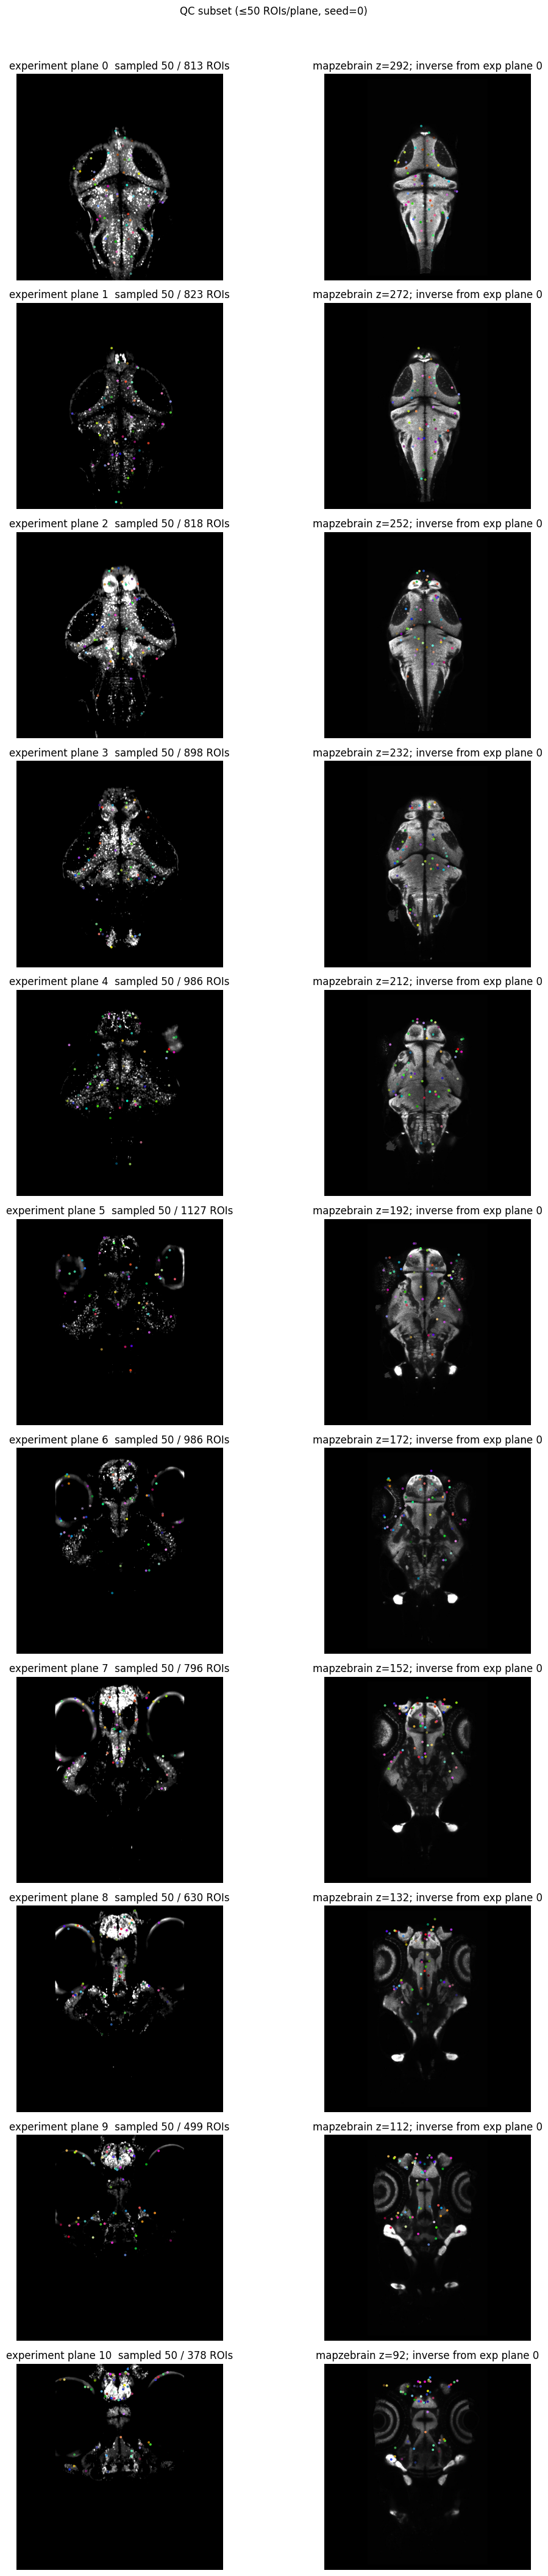

In [17]:
# QC subset: same grid as full QC, but at most N random ROIs per plane (same ALIGNMENT_SAVE_PATH inverse transform).
N_ROIS_SUBSAMPLE_PER_PLANE = 50
QC_SUBSAMPLE_SEED = 0
if "target_img_by_plane" not in globals() or not target_img_by_plane:
    raise RuntimeError("Run the mesmerize / mapping cells above first.")
if "ALIGNMENT_SAVE_PATH" not in globals():
    raise RuntimeError("Run the alignment path check cell above first.")
if "atlas_slice_embedded" not in globals():
    raise RuntimeError("Run the EXPERIMENT_TO_MAPZEBRAIN_Z cell (defines atlas_slice_embedded) first.")
W_EMBED = 1024
SHIFT_X_CURRENT = (1024 - 640) // 2
if "com_to_target_xy" not in globals():
    def com_to_target_xy(x, y):
        px, py = float(x), float(y)
        ox, oy = py, W_EMBED - 1 - px
        return (ox + SHIFT_X_CURRENT, oy)
_fish_id_q = int(exp_folder.name.split("_")[-2])
_h5c = [
    exp_folder / "temporal_pack_compact.h5",
    globals().get("data_folder", exp_folder.parent) / "temporal_pack_compact.h5",
]
_h5c = [Path(x) for x in _h5c]
_h5q = next((p for p in _h5c if p.is_file()), None)
if _h5q is None:
    raise FileNotFoundError("temporal_pack_compact.h5 not found for QC.")
_dfq = df if "df" in globals() else pd.read_hdf(_h5q)
_fishq = _dfq[_dfq["fish_id"] == _fish_id_q]
def _unpack_com_q(c):
    v = np.asarray(c, dtype=float).ravel()
    if v.size < 2:
        raise ValueError(f"COM must have at least 2 values, got {c!r}")
    return float(v[0]), float(v[1])
if EXPERIMENT_ATLAS_QC_PAIRS:
    _qc_rows_s = [(int(ep), int(mz)) for ep, mz in EXPERIMENT_ATLAS_QC_PAIRS if ep in target_img_by_plane]
else:
    _planes_fb = sorted(
        p for p in target_img_by_plane.keys() if p in set(_fishq["plane"].unique())
    ) or sorted(target_img_by_plane.keys())
    _z0 = int(globals().get("QC_ATLAS_Z_SLICES", globals().get("selected_mapzebrain_z", 292)))
    if isinstance(_z0, (list, tuple)):
        _z0 = int(_z0[0])
    _qc_rows_s = [(p, _z0) for p in _planes_fb]
if not _qc_rows_s:
    raise ValueError("No QC rows: check EXPERIMENT_TO_MAPZEBRAIN_Z and target_img_by_plane.")
_tvmin = globals().get("target_vmin", 0)
_tvmax = globals().get("target_vmax", 1000)
_svmax = globals().get("source_vmax", 1000)
_evmin = float(globals().get("QC_EXPERIMENT_VMIN", _tvmin))
_evmax = float(globals().get("QC_EXPERIMENT_VMAX", min(float(_tvmax), 380.0)))
_n = len(_qc_rows_s)
_fig, _ax = plt.subplots(_n, 2, figsize=(12, 3.8 * _n))
if _n == 1:
    _ax = np.asarray([_ax])
_ss = random.Random(QC_SUBSAMPLE_SEED) if QC_SUBSAMPLE_SEED is not None else random.Random()
_col_rng = np.random.default_rng(int(QC_SUBSAMPLE_SEED) if QC_SUBSAMPLE_SEED is not None else None)
for _i, (_pl, _mz) in enumerate(_qc_rows_s):
    _sub = _fishq[_fishq["plane"] == _pl]
    _idx = list(_sub.index)
    _take = min(int(N_ROIS_SUBSAMPLE_PER_PLANE), len(_idx))
    if _take < len(_idx):
        _idx = _ss.sample(_idx, k=_take)
    _sub_s = _sub.loc[_idx]
    _tgt = target_img_by_plane[_pl]
    _src = atlas_slice_embedded(_mz)
    _pts = [com_to_target_xy(*_unpack_com_q(c)) for c in _sub_s["com"]]
    _outs = sitkalignment.transform_points(Path(ALIGNMENT_SAVE_PATH), _pts) if _pts else []
    _k = len(_outs)
    _col = _col_rng.random((_k, 3)) if _k else np.empty((0, 3))
    _xy_e = np.array(_pts, dtype=float) if _k else np.empty((0, 2))
    _xy_m = np.array(_outs, dtype=float) if _k else np.empty((0, 2))
    _ax[_i, 0].imshow(_tgt, cmap="gray", vmin=_evmin, vmax=_evmax)
    if _k:
        _ax[_i, 0].scatter(_xy_e[:, 0], _xy_e[:, 1], c=_col, s=8, alpha=0.9, linewidths=0)
    _ax[_i, 0].set_title(f"experiment plane {_pl}  sampled {_k} / {len(_sub)} ROIs")
    _ax[_i, 0].axis("off")
    _ax[_i, 1].imshow(_src, cmap="gray", vmin=0, vmax=_svmax)
    if _k:
        _ax[_i, 1].scatter(_xy_m[:, 0], _xy_m[:, 1], c=_col, s=8, alpha=0.9, linewidths=0)
    _ax[_i, 1].set_title(
        f"mapzebrain z={_mz}; inverse from exp plane {ALIGNMENT_REFERENCE_PLANE}"
    )
    _ax[_i, 1].axis("off")
plt.suptitle(
    f"QC subset (≤{N_ROIS_SUBSAMPLE_PER_PLANE} ROIs/plane, seed={QC_SUBSAMPLE_SEED!r})",
    y=1.01,
)
plt.tight_layout()
plt.show()


### Save inverse-transformed COMs to `temporal_pack_compact.h5`

Writes **`com_aligned_mapzebrain`** (Elastix inverse transform of each ROI’s `com` into the atlas / mapzebrain frame) onto the **ROI metadata table** inside the pack file. The code **prefers HDF key `/metadata/df`** when that node exists; otherwise **`/df`**, then other common names. If your file uses a different layout, set `pack_h5_roi_key` in the next cell after inspecting `pd.HDFStore(path).keys()`.

Requires **`ALIGNMENT_SAVE_PATH`** and **`com_to_target_xy`** from the cells above. If in-memory **`df`** already has `com_aligned_mapzebrain`, those values are reused for matching row indices; missing rows are computed from `com` for the current fish only.

If **`FISH_ROI_REGIONS`** exists from the region-assignment cell, the same persist pass also writes **`region_aligned_mapzebrain`** (list of labels from **every** mask under the regions folder that contains the COM) and **`single_region`** (the **first** hit along **`REGION_MASK_PRIORITY_STEMS`** only).


In [19]:
# Persist inverse-transformed COMs (atlas / mapzebrain frame) into temporal_pack_compact.h5.
# Updates the ROI metadata table: prefers HDF key `/metadata/df` when present, otherwise `/df`.
# Set `pack_h5_roi_key` if your file uses a different path (see `pd.HDFStore(path).keys()`).
#
# Requires: `exp_folder`, `ALIGNMENT_SAVE_PATH`, `com_to_target_xy` (same convention as QC cells).

COM_MAPZEBRAIN_COL = "com_aligned_mapzebrain"
REGION_LIST_COL = "region_aligned_mapzebrain"
SINGLE_REGION_COL = "single_region"
pack_h5_roi_key = None  # e.g. "/metadata/df" — must match a key returned by HDFStore.keys()

_h5_candidates = [
    exp_folder / "temporal_pack_compact.h5",
    Path(str(globals().get("data_folder", exp_folder.parent))) / "temporal_pack_compact.h5",
]
_pack_h5_path = next((p for p in _h5_candidates if p.is_file()), None)
if _pack_h5_path is None:
    raise FileNotFoundError(
        "temporal_pack_compact.h5 not found. Tried:\n  "
        + "\n  ".join(str(p) for p in _h5_candidates)
    )
pack_path = Path(_pack_h5_path).resolve()

if "ALIGNMENT_SAVE_PATH" not in globals():
    raise RuntimeError("Run the alignment path cell so ALIGNMENT_SAVE_PATH is defined.")
if "com_to_target_xy" not in globals():
    raise RuntimeError(
        "com_to_target_xy missing — run a cell that defines it (W_EMBED / SHIFT convention)."
    )

_fish_id_s = int(exp_folder.name.split("_")[-2])


def _unpack_com_save(c):
    v = np.asarray(c, dtype=float).ravel()
    if v.size < 2:
        raise ValueError(f"COM must have at least 2 values, got {c!r}")
    return float(v[0]), float(v[1])


def _canonical_hdf_key(store_keys, k):
    ks = [str(x) for x in store_keys]
    cand = str(k)
    if not cand.startswith("/"):
        cand = "/" + cand
    if cand in ks:
        return cand
    for x in ks:
        if x.rstrip("/") == cand.rstrip("/"):
            return x
    return None


def _pick_roi_hdf_key(store) -> str:
    keys = list(store.keys())
    if pack_h5_roi_key is not None:
        hit = _canonical_hdf_key(keys, pack_h5_roi_key)
        if hit is None:
            raise KeyError(
                f"pack_h5_roi_key={pack_h5_roi_key!r} not found. Keys: {keys!r}"
            )
        return hit
    for pref in ("/metadata/df", "/df", "/roi_df", "/rois"):
        hit = _canonical_hdf_key(keys, pref)
        if hit is not None:
            return hit
    if len(keys) == 1:
        return keys[0]
    raise ValueError(
        "Could not pick the ROI metadata table key automatically. "
        f"keys={keys!r} — set pack_h5_roi_key at the top of this cell."
    )


def _com_xy_tuple(val):
    if val is None:
        return None
    if isinstance(val, (list, tuple)) and len(val) >= 2:
        return (float(val[0]), float(val[1]))
    a = np.asarray(val, dtype=float).ravel()
    if a.size >= 2:
        return (float(a[0]), float(a[1]))
    return None


with pd.HDFStore(pack_path, "r") as _st_save:
    roi_key = _pick_roi_hdf_key(_st_save)
    try:
        _stor = _st_save.get_storer(roi_key)
        _h5_fmt = getattr(_stor, "format", None) or "fixed"
    except Exception:
        _h5_fmt = "fixed"

full_md = pd.read_hdf(pack_path, key=roi_key)
if "com" not in full_md.columns:
    raise KeyError(f"No 'com' column on HDF key {roi_key!r}")

if "fish_id" in full_md.columns:
    _fish_sel = full_md["fish_id"] == _fish_id_s
else:
    _fish_sel = pd.Series(True, index=full_md.index)

if COM_MAPZEBRAIN_COL not in full_md.columns:
    full_md[COM_MAPZEBRAIN_COL] = pd.Series(index=full_md.index, dtype=object)

_tr_path = Path(ALIGNMENT_SAVE_PATH)
_indices = []
_points = []
for _idx in full_md.index[_fish_sel]:
    _xy = None
    if "df" in globals() and _idx in df.index and COM_MAPZEBRAIN_COL in getattr(df, "columns", []):
        _xy = _com_xy_tuple(df.at[_idx, COM_MAPZEBRAIN_COL])
    if _xy is not None:
        full_md.at[_idx, COM_MAPZEBRAIN_COL] = _xy
        continue
    _indices.append(_idx)
    _points.append(com_to_target_xy(*_unpack_com_save(full_md.at[_idx, "com"])))

if _points:
    _mapped = sitkalignment.transform_points(_tr_path, _points)
    for _idx, _pt in zip(_indices, _mapped):
        full_md.at[_idx, COM_MAPZEBRAIN_COL] = (float(_pt[0]), float(_pt[1]))

if "FISH_ROI_REGIONS" in globals():
    _fr = FISH_ROI_REGIONS
    _ixr = _fr.index.intersection(full_md.index)
    for _rc in (REGION_LIST_COL, SINGLE_REGION_COL):
        if _rc not in full_md.columns:
            full_md[_rc] = pd.Series(index=full_md.index, dtype=object)
    if len(_ixr):
        full_md.loc[_ixr, REGION_LIST_COL] = _fr.loc[_ixr, REGION_LIST_COL]
        full_md.loc[_ixr, SINGLE_REGION_COL] = _fr.loc[_ixr, SINGLE_REGION_COL]
else:
    print(
        "[INFO] FISH_ROI_REGIONS not defined — skipping H5 columns "
        f"{REGION_LIST_COL!r} and {SINGLE_REGION_COL!r} (run region cell first)."
    )

full_md.to_hdf(pack_path, key=roi_key, mode="a", format=_h5_fmt, append=False)

if "df" in globals():
    _sync = full_md.index.intersection(df.index)
    if len(_sync):
        if COM_MAPZEBRAIN_COL not in df.columns:
            df[COM_MAPZEBRAIN_COL] = pd.Series(index=df.index, dtype=object)
        df.loc[_sync, COM_MAPZEBRAIN_COL] = full_md.loc[_sync, COM_MAPZEBRAIN_COL]
        for _rc in (REGION_LIST_COL, SINGLE_REGION_COL):
            if _rc in full_md.columns:
                if _rc not in df.columns:
                    df[_rc] = pd.Series(index=df.index, dtype=object)
                df.loc[_sync, _rc] = full_md.loc[_sync, _rc]

_n_fish = int(_fish_sel.sum())
_n_done = int(full_md.loc[_fish_sel, COM_MAPZEBRAIN_COL].notna().sum())
print(
    f"Wrote {pack_path}\n  key={roi_key!r}  format={_h5_fmt!r}  columns={COM_MAPZEBRAIN_COL!r}, "
    f"{REGION_LIST_COL!r}, {SINGLE_REGION_COL!r}\n"
    f"  fish {_fish_id_s}: {_n_done} / {_n_fish} ROI rows (inverse atlas COMs; regions if FISH_ROI_REGIONS was set)."
)


[INFO] FISH_ROI_REGIONS not defined — skipping H5 columns 'region_aligned_mapzebrain' and 'single_region' (run region cell first).


/var/folders/5s/q3x21d8j6jvcnr7nmcb5xkwr0000gn/T/ipykernel_51334/1359179215.py:139: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['raw_norm_temporal', 'norm_temporal', 'com', 'pulse_frames',
       'com_aligned_mapzebrain'],
      dtype='object')]

  full_md.to_hdf(pack_path, key=roi_key, mode="a", format=_h5_fmt, append=False)


Wrote /Volumes/Kobi/DOI_animals_good/temporal_pack_compact.h5
  key='/compact_temporal'  format='fixed'  columns='com_aligned_mapzebrain', 'region_aligned_mapzebrain', 'single_region'
  fish 15: 8754 / 8754 ROI rows (inverse atlas COMs; regions if FISH_ROI_REGIONS was set).


### Region labels (mapzebrain masks)

The next cell loads **every** multi-page TIFF under `MASKS_FOLDER` (stack index = atlas z). It slices at each **`EXPERIMENT_ATLAS_QC_PAIRS`** atlas z, optionally crops like `hindbrain_alignment_to_mapzebrain.ipynb`, **embeds** to 1024 to match **`com_aligned_mapzebrain`** (must already exist on the ROI table from the COM persist step). For each ROI it builds:

- **`region_aligned_mapzebrain`**: a Python **list** of canonical region names for **every** mask file in the folder whose positive voxels contain that ROI’s inverse-transformed COM (sorted mask order: filename stem, then path; duplicates removed; stems mapped with **`REGION_STEM_TO_CANONICAL`**).

- **`single_region`**: exactly **one** label — the first mask in **`REGION_MASK_PRIORITY_STEMS`** (that exists on disk) whose embedded slice contains the COM. Only those priority stems can win; labels use the same canonical mapping.

**`FISH_ROI_REGIONS`** holds the per-fish slice in memory; run the **persist** cell to write `com_aligned_mapzebrain`, `region_aligned_mapzebrain`, and `single_region` into **`temporal_pack_compact.h5`** for overlapping indices.


Run the memmap + `EXPERIMENT_TO_MAPZEBRAIN_Z` cell first so `EXPERIMENT_ATLAS_QC_PAIRS` exists. Ensure `ALIGNMENT_SAVE_PATH` was run so COMs can be inverse-transformed if needed.


In [20]:
# Assign ROIs to mapzebrain regions (in-memory; mirrored onto `df` if present).
# Requires **`com_aligned_mapzebrain`** on the ROI table (run the COM persist / alignment cell first).
# Builds **`region_aligned_mapzebrain`**: list of canonical labels for every mask TIFF under MASKS_FOLDER
# whose embedded slice contains the COM (sorted by stem, then path; duplicates suppressed).
# Builds **`single_region`**: first matching mask in **`REGION_MASK_PRIORITY_STEMS`** only (canonical label).
# Run the **persist** cell afterward to write these columns into `temporal_pack_compact.h5` when `FISH_ROI_REGIONS` is available.

MASKS_FOLDER = Path(r"/Volumes/Kobi/DOI_animals_good/mapZebrain__regions__v2.0.1")
MASK_GLOB = "*.tif"
# If masks live in subfolders, keep True. Set False to only scan the top level of MASKS_FOLDER.
MASK_RECURSIVE = True
# Optional: warn if we do not find this many mask files on disk (set None to skip).
EXPECTED_MASK_COUNT = 114
# Masks are walked in this order for `single_region` only (first hit wins). Stems must match TIFF filenames without extension.
# Duplicate `posterior_tuberculum_(...)` from the atlas list is included only once.
REGION_MASK_PRIORITY_STEMS = [
    "olfactory_bulb",
    "dorsal_telencephalon_(pallium)",
    "ventral_telencephalon_(subpallium)",
    "rostral_hypothalamus",
    "intermediate_hypothalamus_(entire)",
    "caudal_hypothalamus",
    "pituitary",
    "preoptic_region",
    "hypothalamus",
    "posterior_tuberculum_(basal_part_of_prethalamus_and_thalamus)",
    "retina",
    "eminentia_thalami",
    "prethalamus_(ventral_thalamus)",
    "epiphysis",
    "habenula",
    "thalamus_(dorsal_thalamus)",
    "pretectum",
    "prosencephalon_(forebrain)",
    "oculomotor_nucleus",
    "tegmentum",
    "torus_longitudinalis",
    "tectal_neuropil",
    "periventricular_layer",
    "torus_semicircularis",
    "cerebellum",
    "medial_octavolateralis_nucleus",
    "superior_dorsal_medulla_oblongata",
    "anterior_(dorsal)_trigeminal_motor_nucleus",
    "superior_raphe",
    "interpeduncular_nucleus",
    "locus_coeruleus",
    "posterior_(ventral)_trigeminal_motor_nucleus",
    "nucleus_isthmi",
    "superior_ventral_medulla_oblongata_(entire)",
    "facial_motor_nucleus",
    "abducens_motor_nucleus",
    "intermediate_ventral_medulla_oblongata_(entire)",
    "intermediate_dorsal_medulla_oblongata",
    "vagus_motor_nucleus",
    "area_postrema",
    "vagal_sensory_lobe",
    "inferior_dorsal_medulla_oblongata",
    "inferior_olive",
    "inferior_raphe",
    "lateral_reticular_nucleus",
    "inferior_ventral_medulla_oblongata_(entire)",
    "olfactory_epithelium",
    "anterior_lateral_line_ganglion",
    "trigeminal_ganglion",
    "posterior_lateral_line_ganglion",
    "octaval_ganglion",
    "glossopharyngeal_ganglion",
]
# Map specific mask stems → single label stored on each ROI (unlisted stems use the filename stem).
REGION_STEM_TO_CANONICAL = {
    "superior_dorsal_medulla_oblongata": "dorsal_medulla_oblongata",
    "intermediate_dorsal_medulla_oblongata": "dorsal_medulla_oblongata",
    "inferior_dorsal_medulla_oblongata": "dorsal_medulla_oblongata",
    "superior_ventral_medulla_oblongata_(entire)": "ventral_medulla_oblongata",
    "intermediate_ventral_medulla_oblongata_(entire)": "ventral_medulla_oblongata",
    "inferior_ventral_medulla_oblongata_(entire)": "ventral_medulla_oblongata",
}
ATLAS_MASK_ROW_SLICE = slice(None, None, None)
ATLAS_MASK_COL_SLICE = slice(None, None, None)

COM_ALIGNED_COL = "com_aligned_mapzebrain"
REGION_LIST_COLUMN = "region_aligned_mapzebrain"  # list[str]
SINGLE_REGION_COLUMN = "single_region"  # str | None

W_EMBED = 1024
SHIFT_X_CURRENT = (1024 - 640) // 2
if "EXPERIMENT_ATLAS_QC_PAIRS" not in globals() or not EXPERIMENT_ATLAS_QC_PAIRS:
    raise RuntimeError("Run the EXPERIMENT_TO_MAPZEBRAIN_Z cell so EXPERIMENT_ATLAS_QC_PAIRS is defined.")
if "ALIGNMENT_SAVE_PATH" not in globals():
    raise RuntimeError("Run the alignment path check cell (ALIGNMENT_SAVE_PATH).")
if "com_to_target_xy" not in globals():
    def com_to_target_xy(x, y):
        px, py = float(x), float(y)
        ox, oy = py, W_EMBED - 1 - px
        return (ox + SHIFT_X_CURRENT, oy)


def _unpack_com(c):
    v = np.asarray(c, dtype=float).ravel()
    if v.size < 2:
        raise ValueError(f"COM must have at least 2 values, got {c!r}")
    return float(v[0]), float(v[1])


_fish_id = int(exp_folder.name.split("_")[-2])
_h5_candidates = [
    exp_folder / "temporal_pack_compact.h5",
    Path(globals().get("data_folder", exp_folder.parent)) / "temporal_pack_compact.h5",
]
_h5_path = next((p for p in _h5_candidates if p.is_file()), None)
if _h5_path is None:
    raise FileNotFoundError("temporal_pack_compact.h5 not found. Tried:\n  " + "\n  ".join(str(x) for x in _h5_candidates))
with pd.HDFStore(_h5_path, "r") as _st:
    _h5_keys = [k.lstrip("/") for k in _st.keys()]
_h5_key = _h5_keys[0]
_df = pd.read_hdf(_h5_path, key=_h5_key)
_fish = _df[_df["fish_id"] == _fish_id].copy()

if COM_ALIGNED_COL not in _fish.columns:
    raise RuntimeError(
        f"Missing column {COM_ALIGNED_COL!r}. Populate inverse-transformed COMs (persist / alignment cell) before region assignment."
    )
_n_missing_com = int(_fish[COM_ALIGNED_COL].isna().sum())
if _n_missing_com == len(_fish):
    raise RuntimeError(
        f"All ROI rows lack {COM_ALIGNED_COL!r}. Run the COM persist / alignment step first."
    )
if _n_missing_com:
    print(
        f"[WARN] {_n_missing_com} / {len(_fish)} ROIs have no {COM_ALIGNED_COL}; "
        "skipping region tests for those rows."
    )

_fish[REGION_LIST_COLUMN] = pd.Series([[] for _ in range(len(_fish))], index=_fish.index, dtype=object)
_fish[SINGLE_REGION_COLUMN] = pd.Series([None] * len(_fish), index=_fish.index, dtype=object)

if not MASKS_FOLDER.is_dir():
    raise FileNotFoundError(f"MASKS_FOLDER not found: {MASKS_FOLDER.resolve()}")
_mask_paths = []
_iter = MASKS_FOLDER.rglob("*") if MASK_RECURSIVE else MASKS_FOLDER.glob("*")
for _p in _iter:
    if not _p.is_file():
        continue
    if _p.name.startswith(".") or _p.name.startswith("._"):
        continue
    _ln = _p.name.lower()
    if not (_ln.endswith(".tif") or _ln.endswith(".tiff")):
        continue
    _mask_paths.append(_p)
_mask_paths = sorted(set(_mask_paths), key=lambda q: str(q).lower())
print(f"Mask TIFFs found on disk: {len(_mask_paths)} (recursive={MASK_RECURSIVE}) under {MASKS_FOLDER}")
if EXPECTED_MASK_COUNT is not None and len(_mask_paths) < EXPECTED_MASK_COUNT:
    print(
        f"[WARN] Found {len(_mask_paths)} < EXPECTED_MASK_COUNT={EXPECTED_MASK_COUNT}. "
        "Check MASKS_FOLDER, MASK_RECURSIVE, and file extensions."
    )
if not _mask_paths:
    raise FileNotFoundError(f"No .tif/.tiff masks under {MASKS_FOLDER}")
_stem_to_path = {_p.stem: _p for _p in _mask_paths}
_ordered_mask_paths = []
for _stem in REGION_MASK_PRIORITY_STEMS:
    _p = _stem_to_path.get(_stem)
    if _p is not None:
        _ordered_mask_paths.append(_p)
    else:
        print(f"[WARN] priority mask missing on disk: {_stem}.tif (skipped)")
print(f"Priority list: using {len(_ordered_mask_paths)} / {len(REGION_MASK_PRIORITY_STEMS)} listed stems")
_all_mask_paths = sorted(_mask_paths, key=lambda p: (p.stem.lower(), str(p).lower()))


def _embed_mask_slice(stack, mz):
    sl = np.asarray(stack[int(mz)], dtype=np.float64)
    if ATLAS_MASK_ROW_SLICE is not None or ATLAS_MASK_COL_SLICE is not None:
        rs = ATLAS_MASK_ROW_SLICE if ATLAS_MASK_ROW_SLICE is not None else slice(None)
        cs = ATLAS_MASK_COL_SLICE if ATLAS_MASK_COL_SLICE is not None else slice(None)
        sl = sl[rs, cs]
    sl = (sl > 0).astype(np.float64)
    return sitkalignment.embed_image(sl, 1024) > 0.5


def _apply_masks_to_fish(mask_paths, fill_list, fill_single):
    """fill_list: append canonical labels for every hit. fill_single: set first single_region hit only when True."""
    for _mp in mask_paths:
        _mname = _mp.stem
        _label = REGION_STEM_TO_CANONICAL.get(_mname, _mname)
        _stack = tifffile.imread(str(_mp))
        if _stack.ndim < 2:
            raise ValueError(f"{_mp.name}: expected at least 2D, got shape {_stack.shape}")
        for _ep, _mz in EXPERIMENT_ATLAS_QC_PAIRS:
            _ep, _mz = int(_ep), int(_mz)
            if _mz >= _stack.shape[0]:
                print(f"[WARN] {_mname}: atlas z {_mz} >= stack depth {_stack.shape[0]} — skip plane {_ep}")
                continue
            _emb = _embed_mask_slice(_stack, _mz)
            _sub = _fish[_fish["plane"] == _ep]
            _ok = _sub[COM_ALIGNED_COL].notna()
            for _idx in _sub.index[_ok]:
                _xy = _fish.at[_idx, COM_ALIGNED_COL]
                if _xy is None:
                    continue
                xi, yi = int(round(float(_xy[0]))), int(round(float(_xy[1])))
                if xi < 0 or yi < 0 or yi >= _emb.shape[0] or xi >= _emb.shape[1]:
                    continue
                if _emb[yi, xi]:
                    if fill_list:
                        _lst = _fish.at[_idx, REGION_LIST_COLUMN]
                        if _label not in _lst:
                            _lst.append(_label)
                    if fill_single and _fish.at[_idx, SINGLE_REGION_COLUMN] is None:
                        _fish.at[_idx, SINGLE_REGION_COLUMN] = _label


_apply_masks_to_fish(_all_mask_paths, fill_list=True, fill_single=False)
_apply_masks_to_fish(_ordered_mask_paths, fill_list=False, fill_single=True)

MASK_PATHS_ALL = list(_all_mask_paths)
MASK_PATHS_PRIORITY_USED = list(_ordered_mask_paths)
FISH_ROI_REGIONS = _fish.copy()
# Mirror aligned COM + region columns into in-memory `df` (no HDF5 write here).
if "df" in globals():
    _ix_merge = _fish.index.intersection(df.index)
    if len(_ix_merge) < len(_fish):
        print(
            f"[WARN] `df` index mismatch: updating {len(_ix_merge)} / {len(_fish)} ROI rows in `df`."
        )
    if len(_ix_merge):
        for _c in (COM_ALIGNED_COL, REGION_LIST_COLUMN, SINGLE_REGION_COLUMN):
            if _c not in df.columns:
                df[_c] = pd.Series(index=df.index, dtype=object)
            df.loc[_ix_merge, _c] = _fish.loc[_ix_merge, _c]

_n_single = int(_fish[SINGLE_REGION_COLUMN].notna().sum())
_n_multi = int((_fish[REGION_LIST_COLUMN].map(len) > 0).sum())
print(
    f"fish {_fish_id}: single_region={_n_single} / {len(_fish)} ROIs; "
    f"region_aligned_mapzebrain non-empty lists={_n_multi} / {len(_fish)} — "
    f"FISH_ROI_REGIONS; `df` updated in-memory if present (run persist cell for HDF5)."
)


Mask TIFFs found on disk: 113 (recursive=True) under /Volumes/Kobi/DOI_animals_good/mapZebrain__regions__v2.0.1
[WARN] Found 113 < EXPECTED_MASK_COUNT=114. Check MASKS_FOLDER, MASK_RECURSIVE, and file extensions.
Priority list: using 52 / 52 listed stems
fish 15: single_region=7460 / 8754 ROIs; region_aligned_mapzebrain non-empty lists=7460 / 8754 — FISH_ROI_REGIONS; `df` updated in-memory if present (run persist cell for HDF5).
